In the last notebook we took a language model apart and watched it predict the next word.
Let's recall that first. 

Input → Tokenization → Model → Logits (Raw scores) → Softmax → Probabilities → Select next token

At the very end we picked the **greedy decoding** — we just grabbed the single highest-scoring token every single time. That works, but it has a personality problem: ask the same question twice and you get the *exact* same answer, word for word.

In this notebook we will learn about Temperature which can change the personality and output of the mode. 

We'll use the same small open model, **Qwen3-0.6B**



1. **Where we left off** — greedy decoding gives one fixed answer
2. **What temperature does** — dividing the logits before softmax
3. **Cold and hot** — how temperature changes the probabilities
4. **Seeing it change** — the same tokens plotted at three temperatures
5. **Sampling** — picking a token by its probability 
6. **Generating text** — the loop that writes, now with a temperature dial
7. **Which temperature to use** — matching the value to the task

## Setup — Load the Model and Tokenizer
Same two steps as before: the tokenizer, which turns text into numbers, and the model itself.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-0.6B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto",
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Creating a GenerationConfig.

A GenerationConfig is a settings object used to control how a large language model (LLM) creates text.

If we make `do_sample = False`, then it will just do the greedy method and won't use any config we give it. Right now we want to learn about temperature so `do_sample = True`.

About the max new tokens, it is the  maximum number of new tokens the model is allowed to generate, ignoring how long your input prompt is. Before we used to use max_length  which controls the total length of both the input prompt and the output combined.

In [6]:
from transformers import GenerationConfig

model.generation_config = GenerationConfig(
    do_sample=True,
    temperature=0.3,
    top_p=0.9,
    max_new_tokens=10,
)

Encoding the input 


In [7]:
tokenizer.encode("The old house at the end of the street was")

[785, 2310, 3753, 518, 279, 835, 315, 279, 8592, 572]

Decoding for fun 


In [8]:
tokenizer.decode(8592)

' street'

Now we write the prompt.

`return_tensors="pt"` tells the tokenizer to return PyTorch tensors (vectors) instead of  Python lists.

There are some special tokens in llms. For example - "`<|endoftext|>`", it tells the llm the end of text. We don't want these in the output , that's why we use `skip_special_tokens=True` it skips all the special tokens from the output.

In [9]:
prompt = "The old house at the end of the street was" 
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

output = model.generate(**inputs)


print(tokenizer.decode(output[0], skip_special_tokens=True))

The old house at the end of the street was a small one. The new house is a large


In [10]:
output    #returns token IDs

tensor([[ 785, 2310, 3753,  518,  279,  835,  315,  279, 8592,  572,  264, 2613,
          825,   13,  576,  501, 3753,  374,  264, 3460]])

## Cold and hot — how temperature changes the probabilities

The plots below reshape the model's next-token scores at different temperatures. For that we first need the **logits** for the position right after the prompt. Run the model once on `inputs` and keep the last position.

In [11]:
import torch

with torch.no_grad():
    out = model(**inputs)

logits = out.logits[0, -1, :]   # raw scores for the next token, shape [vocab_size]

## Plotting and visualizing

Here we plot the probabilites on the graph with different Temperatures. 

When the Temperature is less than 1 . (T<1)

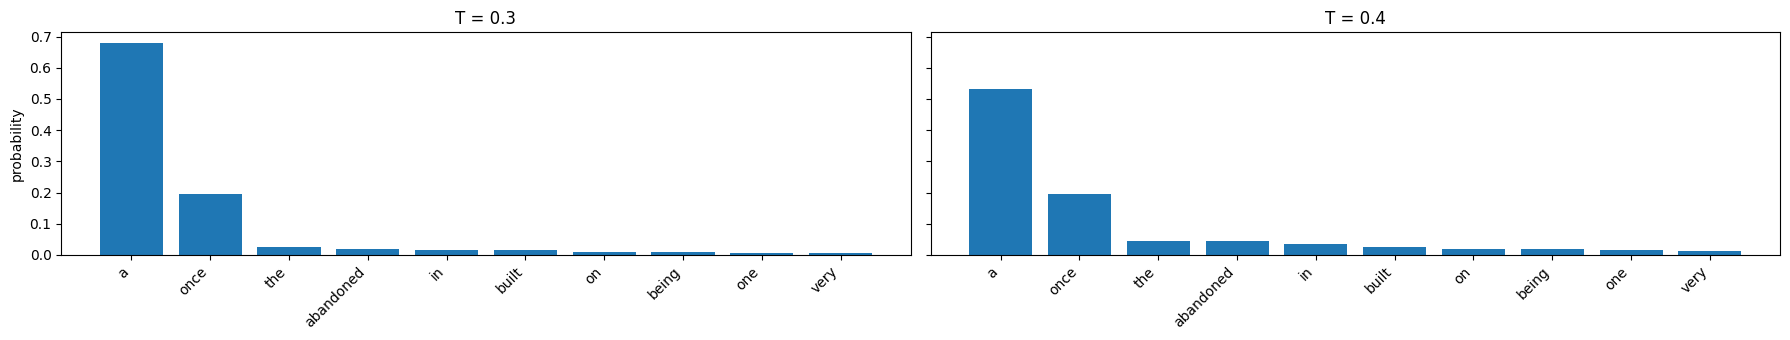

In [12]:
import matplotlib.pyplot as plt
import torch

temps = [0.3, 0.4]   # Temperature < 1
k = 10

base_probs = torch.softmax(logits, dim=-1)
top_idx = torch.topk(base_probs, k).indices
labels = [tokenizer.decode(int(i)).strip() or "␣" for i in top_idx]

fig, axes = plt.subplots(1, len(temps), figsize=(18, 3.5), sharey=True)
for ax, T in zip(axes, temps):
    p = torch.softmax(logits / T, dim=-1)[top_idx]
    ax.bar(range(k), p.float().detach().cpu().numpy())
    ax.set_xticks(range(k))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(f"T = {T}")
axes[0].set_ylabel("probability")
plt.tight_layout()
plt.show()

When the Temperature is more than 1 . (T>1)

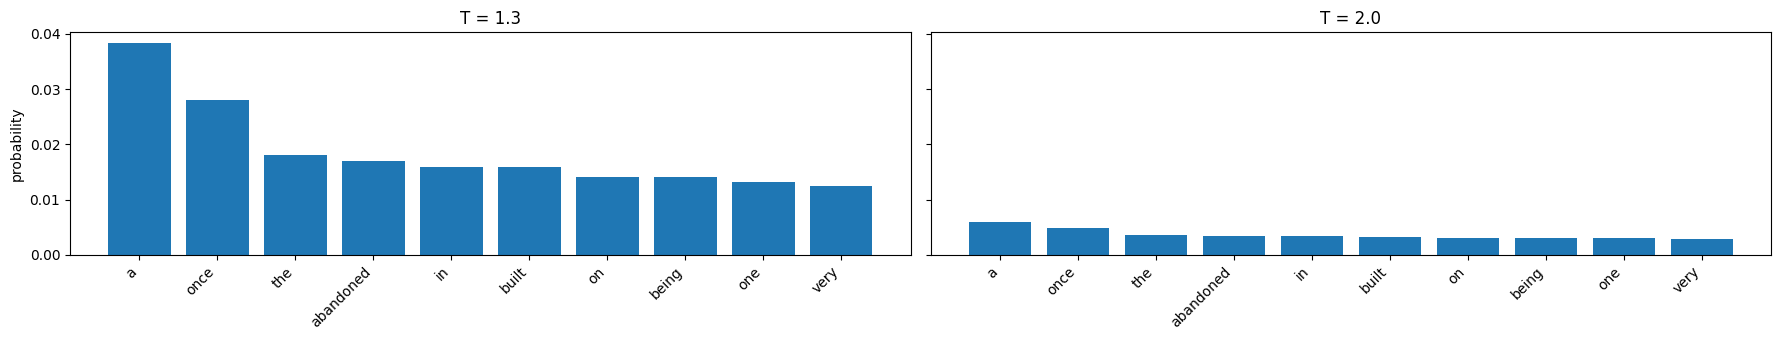

In [13]:
import matplotlib.pyplot as plt
import torch

temps = [1.3, 2.0]   # Temperature > 1
k = 10

base_probs = torch.softmax(logits, dim=-1)
top_idx = torch.topk(base_probs, k).indices
labels = [tokenizer.decode(int(i)).strip() or "␣" for i in top_idx]

fig, axes = plt.subplots(1, len(temps), figsize=(18, 3.5), sharey=True)
for ax, T in zip(axes, temps):
    p = torch.softmax(logits / T, dim=-1)[top_idx]
    ax.bar(range(k), p.float().detach().cpu().numpy())
    ax.set_xticks(range(k))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(f"T = {T}")
axes[0].set_ylabel("probability")
plt.tight_layout()
plt.show()

## Sampling — picking a token by its probability

The plots show the probabilities, but to actually generate text the model has to pick one token. We do that with `torch.multinomial`, which chooses a token based on its probability. Tokens with a higher probability get picked more often, though the top one isn't always the one chosen. Running this a few times shows the effect of temperature: at 0.3 the choice stays almost the same each time, while at 1.3 it varies much more.

In [14]:
for T in [0.3, 1.3]:
    probs = torch.softmax(logits / T, dim=-1)
    picks = [torch.multinomial(probs, num_samples=1).item() for _ in range(8)]
    words = [tokenizer.decode(p).strip() for p in picks]
    print(f"T={T}: {words}")

T=0.3: ['a', 'once', 'a', 'a', 'a', 'once', 'a', 'a']
T=1.3: ['Once', 'black', 'renovated', 'said', 'aud', '', 'unanimously', 'recently']


## Which temperature to use

There's no single right value, it depends on the task.

- **0.1 – 0.4 (low):** factual answers, code, math problems (when you want the most likely token).
- **0.7 – 1.0 (medium):** general chat, varied but still coherent.
- **1.2 – 1.5 (high):** brainstorming and creative writing.
- **above 2.0:** usually incoherent, too much probability goes to unlikely tokens.

